In [9]:

import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

plt.rcParams['figure.dpi'] = 110
plt.rcParams['savefig.dpi'] = 110
plt.rcParams['font.size'] = 9
plt.rcParams['axes.grid'] = True
plt.rcParams['grid.alpha'] = 0.3

# --- 日本語フォント設定（macOS/Linux/Windows 自動選択） ---
from matplotlib import font_manager as fm
_jp_candidates = ['Hiragino Maru Gothic Pro', 'Hiragino Sans',
                  'Yu Gothic', 'Meiryo',
                  'Noto Sans CJK JP', 'IPAexGothic', 'IPAGothic',
                  'TakaoPGothic', 'Arial Unicode MS']
_avail = {f.name for f in fm.fontManager.ttflist}
_jp_font = next((f for f in _jp_candidates if f in _avail), None)
if _jp_font:
    plt.rcParams['font.family'] = _jp_font
    print(f'[matplotlib] Japanese font set: {_jp_font}')
else:
    print('[matplotlib] No Japanese font found.')
plt.rcParams['axes.unicode_minus'] = False


[matplotlib] Japanese font set: Hiragino Maru Gothic Pro


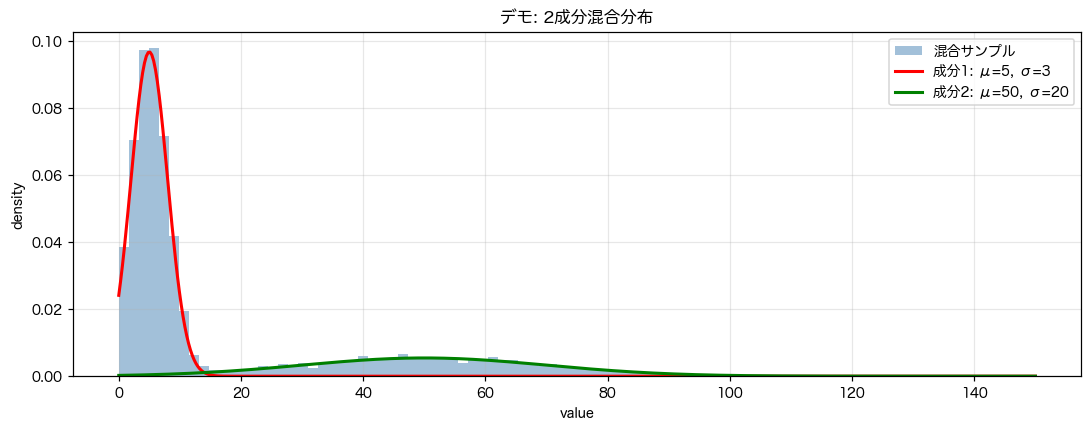

サンプル数: 10581


In [10]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import norm

rng = np.random.default_rng(42)

# 2つの正規分布からサンプリング
mu1, sigma1, n1 = 5,  3,  8000   # 安静っぽい成分
mu2, sigma2, n2 = 50, 20, 3000   # 活動っぽい成分

samples1 = rng.normal(mu1, sigma1, n1)
samples2 = rng.normal(mu2, sigma2, n2)

# 混合（正の値のみ）
X_demo = np.concatenate([samples1, samples2])
X_demo = X_demo[X_demo > 0]

# 可視化
fig, ax = plt.subplots(figsize=(10, 4))
ax.hist(X_demo, bins=80, density=True, alpha=0.5, color='steelblue', label='混合サンプル')

# 真の分布を重ね描き
x = np.linspace(0, 150, 500)
w1 = n1 / (n1 + n2)
w2 = n2 / (n1 + n2)
ax.plot(x, w1 * norm.pdf(x, mu1, sigma1), 'r-', lw=2, label=f'成分1: μ={mu1}, σ={sigma1}')
ax.plot(x, w2 * norm.pdf(x, mu2, sigma2), 'g-', lw=2, label=f'成分2: μ={mu2}, σ={sigma2}')

ax.set_xlabel('value')
ax.set_ylabel('density')

ax.legend()
ax.set_title('デモ: 2成分混合分布')
plt.tight_layout()
plt.show()

print(f'サンプル数: {len(X_demo)}')

=== 推定結果 ===
成分1: μ=5.29, σ=2.69, weight=0.72
成分2: μ=50.04, σ=19.90, weight=0.28

=== 真の値 ===
成分1: μ=5, σ=3, weight=0.73
成分2: μ=50, σ=20, weight=0.27


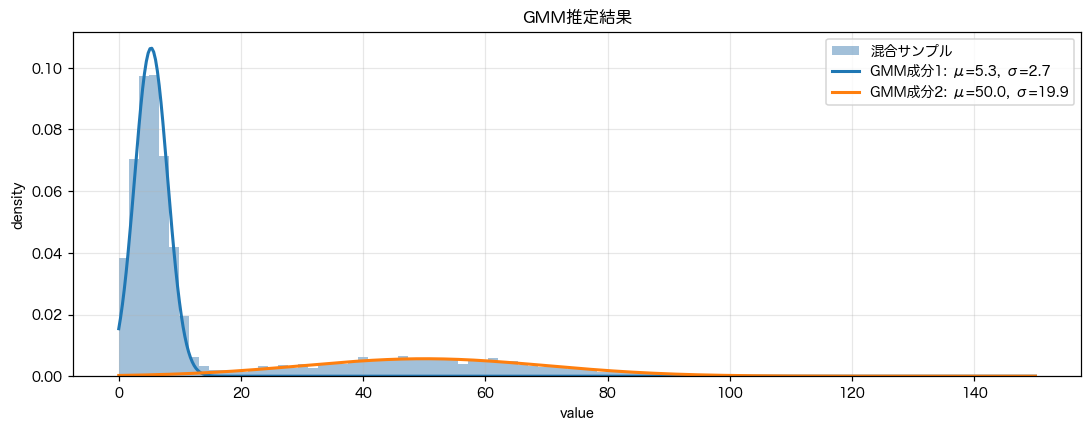

In [11]:
from sklearn.mixture import GaussianMixture

# GMMの当てはめ
X = X_demo.reshape(-1, 1)
gmm = GaussianMixture(n_components=2, random_state=0)
gmm.fit(X)

# 推定結果
means = gmm.means_.flatten()
stds = np.sqrt(gmm.covariances_.flatten())
weights = gmm.weights_

print('=== 推定結果 ===')
for i in range(2):
    print(f'成分{i+1}: μ={means[i]:.2f}, σ={stds[i]:.2f}, weight={weights[i]:.2f}')

print('\n=== 真の値 ===')
print(f'成分1: μ={mu1}, σ={sigma1}, weight={w1:.2f}')
print(f'成分2: μ={mu2}, σ={sigma2}, weight={w2:.2f}')

# 可視化
fig, ax = plt.subplots(figsize=(10, 4))
ax.hist(X_demo, bins=80, density=True, alpha=0.5, color='steelblue', label='混合サンプル')

x = np.linspace(0, 150, 500)
for i in range(2):
    ax.plot(x, weights[i] * norm.pdf(x, means[i], stds[i]),
            lw=2, label=f'GMM成分{i+1}: μ={means[i]:.1f}, σ={stds[i]:.1f}')

ax.set_xlabel('value')
ax.set_ylabel('density')

ax.legend()
ax.set_title('GMM推定結果')
plt.tight_layout()
plt.show()